# Step 0 — Mesh bootstrap

**Prerequisites:** `data/sample.glb` only (no SAM3D checkpoints, no Gaussian splat).

**Pass checklist (last cell):**
- Mesh loads with V > 0, F > 0
- After normalization: center ≈ 0, max vertex radius ≈ 1
- Bounds are finite and non-degenerate

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import trimesh

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from datasets.mesh_loading import load_mesh, normalize_mesh
from utils.config import load_config, resolve_path

In [2]:
cfg = load_config()
mesh_path = resolve_path(cfg["rendering"]["mesh_path"])
print("mesh:", mesh_path)
assert mesh_path.exists(), f"Missing mesh: {mesh_path}"

mesh = load_mesh(mesh_path)
print(f"vertices={mesh.num_vertices}, faces={mesh.num_faces}")
lo, hi = mesh.bounds()
print(f"bounds min={lo}, max={hi}, center={mesh.center()}")

mesh: /Users/mattiskrauch/Documents/Studium/Semester 4/ADL4CV/affordance-prediction/data/sample.glb
vertices=5328, faces=9499
bounds min=[-0.06505432 -0.0015359  -0.09671149], max=[0.06480409 0.1660649  0.18711028], center=[-0.00117454  0.10011049  0.0145022 ]


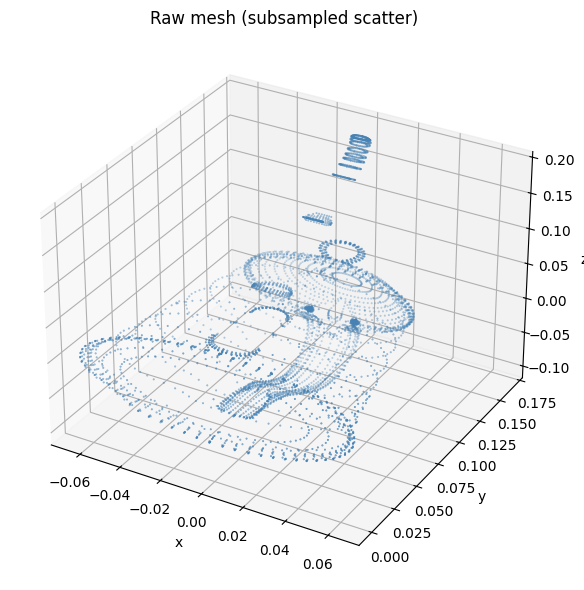

In [3]:
tm = trimesh.Trimesh(vertices=mesh.vertices, faces=mesh.faces, process=False)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2], s=0.2, c="steelblue")
ax.set_title("Raw mesh (subsampled scatter)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()

normalized center=[-4.2238137e-09 -3.5426058e-07  2.0281017e-07], max radius=1.000000


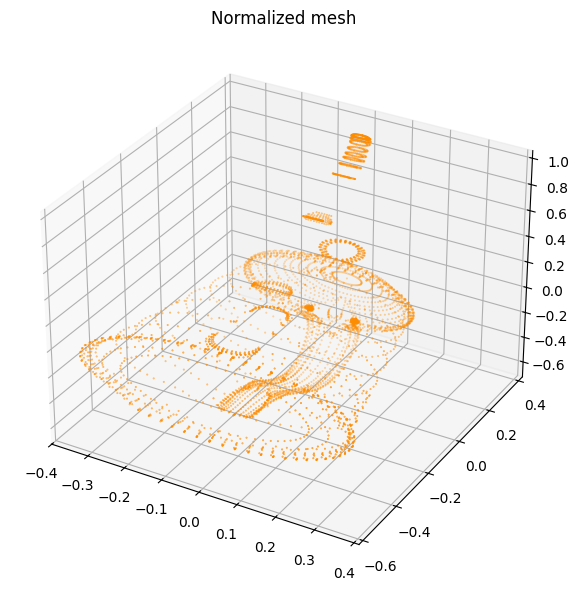

In [4]:
norm = normalize_mesh(mesh, center=True, unit_scale=True)
radius = np.linalg.norm(norm.vertices, axis=1).max()
center = norm.vertices.mean(axis=0)
print(f"normalized center={center}, max radius={radius:.6f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(norm.vertices[:, 0], norm.vertices[:, 1], norm.vertices[:, 2], s=0.2, c="darkorange")
ax.set_title("Normalized mesh")
plt.tight_layout()
plt.show()

In [5]:
# --- Pass checklist ---
assert mesh.num_vertices > 0 and mesh.num_faces > 0
assert np.isfinite(mesh.vertices).all()
assert np.linalg.norm(center) < 1e-4, center
assert abs(radius - 1.0) < 1e-3, radius
lo, hi = norm.bounds()
assert np.isfinite(lo).all() and np.isfinite(hi).all()
assert (hi - lo).max() > 0.1
print("PASS: Step 0 mesh bootstrap")

PASS: Step 0 mesh bootstrap
